In [ ]:
import pandas as pd
import numpy as np
import io
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nFirst row preview:")
df.head(2)

Shape: (7043, 21)

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First row preview:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

print("Nulls in totalcharges:", df['totalcharges'].isna().sum())

df['totalcharges'].fillna(df['totalcharges'].median(), inplace=True)

print("Fixed. No nulls remaining:", df['totalcharges'].isna().sum())

Nulls in totalcharges: 11
Fixed. No nulls remaining: 0


/tmp/ipykernel_681/3599562378.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['totalcharges'].fillna(df['totalcharges'].median(), inplace=True)


In [ ]:
# ---- Step 6: Split into 4 dataframes ----

dim_customers = df[[
    'customerid','gender','seniorcitizen','partner','dependents'
]].copy()
dim_customers.columns = [
    'customer_id','gender','senior_citizen','partner','dependents'
]

dim_services = df[[
    'customerid','phoneservice','multiplelines','internetservice',
    'onlinesecurity','onlinebackup','deviceprotection',
    'techsupport','streamingtv','streamingmovies'
]].copy()
dim_services.columns = [
    'customer_id','phone_service','multiple_lines','internet_service',
    'online_security','online_backup','device_protection',
    'tech_support','streaming_tv','streaming_movies'
]

dim_contracts = df[[
    'customerid','contract','paperlessbilling','paymentmethod'
]].copy()
dim_contracts.columns = [
    'customer_id','contract','paperless_billing','payment_method'
]

fact_billing = df[[
    'customerid','tenure','monthlycharges','totalcharges','churn'
]].copy()
fact_billing.columns = [
    'customer_id','tenure','monthly_charges','total_charges','churn'
]

# ---- Step 7: Verify all 4 dataframes ----
print("=" * 40)
print(f"dim_customers : {dim_customers.shape[0]} rows, {dim_customers.shape[1]} cols")
print(f"dim_services  : {dim_services.shape[0]} rows, {dim_services.shape[1]} cols")
print(f"dim_contracts : {dim_contracts.shape[0]} rows, {dim_contracts.shape[1]} cols")
print(f"fact_billing  : {fact_billing.shape[0]} rows, {fact_billing.shape[1]} cols")
print("=" * 40)
print("\nSample dim_customers:")
print(dim_customers.head(3))
print("\nSample fact_billing:")
print(fact_billing.head(3))

dim_customers : 7043 rows, 5 cols
dim_services  : 7043 rows, 10 cols
dim_contracts : 7043 rows, 4 cols
fact_billing  : 7043 rows, 5 cols

Sample dim_customers:
  customer_id  gender  senior_citizen partner dependents
0  7590-VHVEG  Female               0     Yes         No
1  5575-GNVDE    Male               0      No         No
2  3668-QPYBK    Male               0      No         No

Sample fact_billing:
  customer_id  tenure  monthly_charges  total_charges churn
0  7590-VHVEG       1            29.85          29.85    No
1  5575-GNVDE      34            56.95        1889.50    No
2  3668-QPYBK       2            53.85         108.15   Yes


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['axes.titlesize']=14
plt.rcParams['axes.titleweight']='bold'
print("Libraries ready. Let's begin EDA.")

Libraries ready. Let's begin EDA.


In [ ]:
print('='*50)
print(df.shape)
print('='*50)
print('\nData Types:' )
print(df.dtypes)
print(df.isnull().sum())
df[['tenure', 'monthlycharges', 'totalcharges']].describe().round(2)

(7043, 21)

Data Types:
customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                object
dtype: object
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0


,tenure,monthlycharges,totalcharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


In [ ]:
churn_counts= df['churn'].value_counts()
churn_pct= df['churn'].value_counts(normalize=True)
print(churn_counts)
print(churn_pct.round(2))


churn
No     5174
Yes    1869
Name: count, dtype: int64
churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64


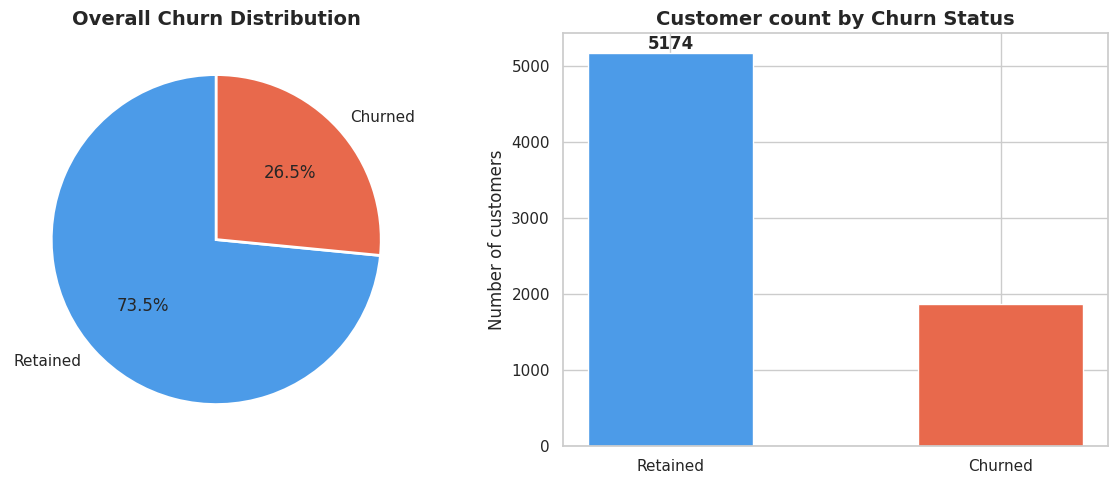

<Figure size 1000x500 with 0 Axes>

In [ ]:
from matplotlib import axes
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].pie(
    churn_counts,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#E8694C'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Churn Distribution')
bars=axes[1].bar(
    ['Retained',"Churned"],
    churn_counts.values,
    color=['#4C9BE8', '#E8694C'],
    edgecolor='white', width=0.5
)
axes[1].set_title('Customer count by Churn Status')
axes[1].set_ylabel('Number of customers')
for bar,count in zip(bars,churn_counts.values):
  axes[1].text(
      bar.get_x()+bar.get_width()/2,
      bar.get_height()+50,
      str(count),
      ha='center',
      fontweight='bold'
  )
  plt.tight_layout()
  plt.savefig('churn_overview.png',dpi=200,bbox_inches='tight')
  plt.show()

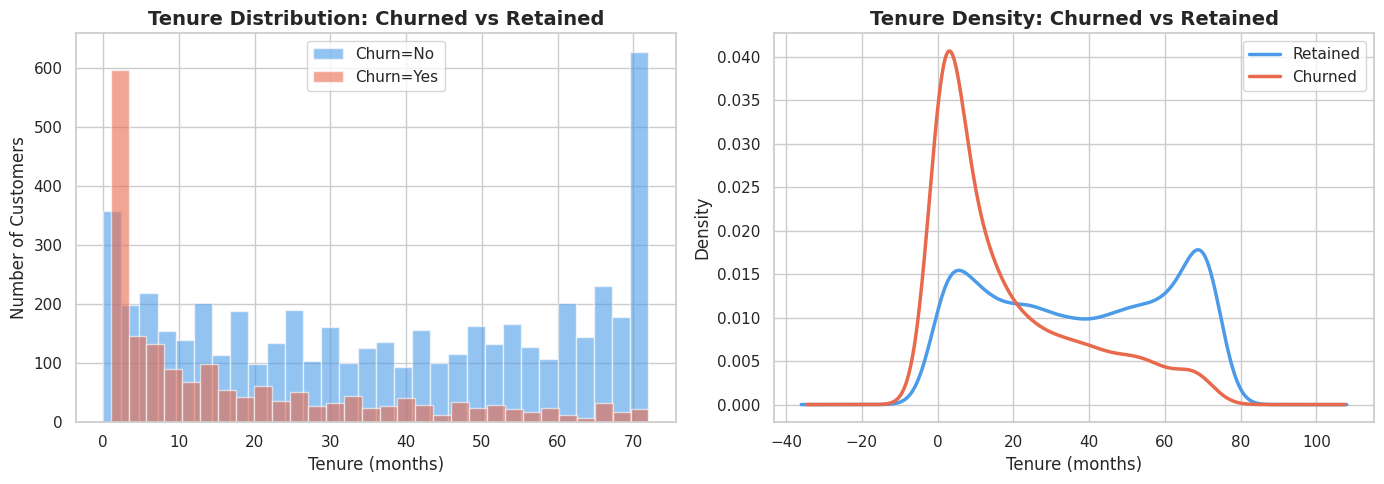

Average tenure — Retained: 37.6 months
Average tenure — Churned : 18.0 months


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of tenure for churned vs retained
for label, color in [('No', '#4C9BE8'), ('Yes', '#E8694C')]:
    subset = df[df['churn'] == label]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f"Churn={label}", edgecolor='white')

axes[0].set_title('Tenure Distribution: Churned vs Retained')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# KDE (smooth curve) version — easier to compare shapes
df[df['churn']=='No']['tenure'].plot.kde(ax=axes[1], color='#4C9BE8',
                                          linewidth=2.5, label='Retained')
df[df['churn']=='Yes']['tenure'].plot.kde(ax=axes[1], color='#E8694C',
                                           linewidth=2.5, label='Churned')
axes[1].set_title('Tenure Density: Churned vs Retained')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print averages
print("Average tenure — Retained:", round(df[df['churn']=='No']['tenure'].mean(), 1), "months")
print("Average tenure — Churned :", round(df[df['churn']=='Yes']['tenure'].mean(), 1), "months")

/tmp/ipykernel_681/4238062985.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


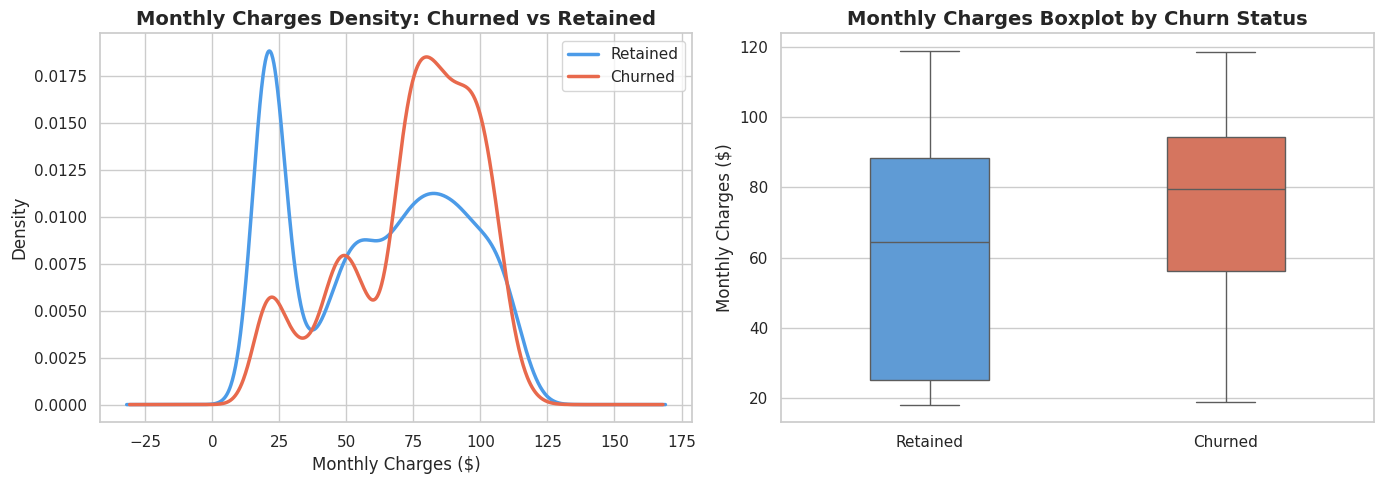

Median Monthly Charges — Retained: 64.43
Median Monthly Charges — Churned : 79.65

Insight: Churned customers pay significantly more. High charges = high churn risk.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE comparison
df[df['churn']=='No']['monthlycharges'].plot.kde(
    ax=axes[0], color='#4C9BE8', linewidth=2.5, label='Retained')
df[df['churn']=='Yes']['monthlycharges'].plot.kde(
    ax=axes[0], color='#E8694C', linewidth=2.5, label='Churned')
axes[0].set_title('Monthly Charges Density: Churned vs Retained')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

# Boxplot
df_plot = df[['churn','monthlycharges']].copy()
df_plot['churn_label'] = df_plot['churn'].map({'No':'Retained','Yes':'Churned'})

sns.boxplot(
    data=df_plot, x='churn_label', y='monthlycharges',
    palette={'Retained':'#4C9BE8','Churned':'#E8694C'},
    ax=axes[1], width=0.4
)
axes[1].set_title('Monthly Charges Boxplot by Churn Status')
axes[1].set_xlabel('')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print("Median Monthly Charges — Retained:", round(df[df['churn']=='No']['monthlycharges'].median(), 2))
print("Median Monthly Charges — Churned :", round(df[df['churn']=='Yes']['monthlycharges'].median(), 2))
print("\nInsight: Churned customers pay significantly more. High charges = high churn risk.")

         contract  churn_rate
0  Month-to-month   42.709677
1        One year   11.269518
2        Two year    2.831858


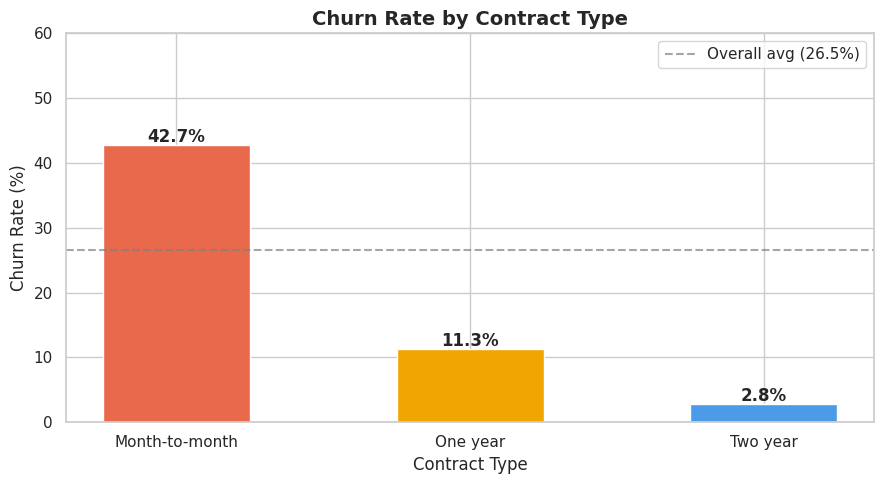


Insight: Month-to-month customers churn at ~42% vs 11% (1yr) and 3% (2yr).
Contract type is your #1 predictor. Locking users into annual plans = biggest retention lever.


In [ ]:
contract_churn = df.groupby('contract')['churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['contract', 'churn_rate']
contract_churn = contract_churn.sort_values('churn_rate', ascending=False)

print(contract_churn)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    contract_churn['contract'],
    contract_churn['churn_rate'],
    color=['#E8694C', '#F0A500', '#4C9BE8'],
    edgecolor='white', width=0.5
)

# Add percentage labels on bars
for bar, val in zip(bars, contract_churn['churn_rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12
    )

ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
ax.axhline(y=26.5, color='gray', linestyle='--', alpha=0.7, label='Overall avg (26.5%)')
ax.legend()

plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Month-to-month customers churn at ~42% vs 11% (1yr) and 3% (2yr).")
print("Contract type is your #1 predictor. Locking users into annual plans = biggest retention lever.")

/tmp/ipykernel_681/2248986671.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


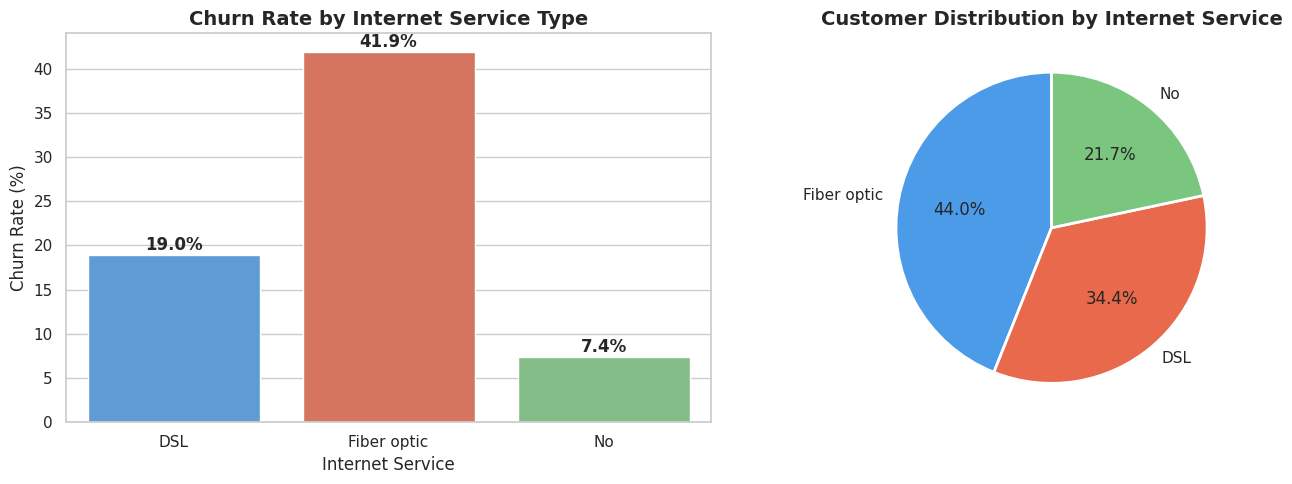


Insight: Fiber optic customers churn the most (~42%) despite paying the highest charges.
This is counterintuitive — suggests a service quality or value-perception problem.
This is a PRODUCT finding, not just a data finding.


In [ ]:


internet_churn = df.groupby('internetservice')['churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
internet_churn.columns = ['internet_service', 'churn_rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate bar
sns.barplot(
    data=internet_churn, x='internet_service', y='churn_rate',
    palette=['#4C9BE8','#E8694C','#7BC67E'], ax=axes[0]
)
axes[0].set_title('Churn Rate by Internet Service Type')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Churn Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                     ha='center', fontweight='bold')

# Count of customers by service type
internet_counts = df['internetservice'].value_counts()
axes[1].pie(
    internet_counts.values,
    labels=internet_counts.index,
    autopct='%1.1f%%',
    colors=['#4C9BE8','#E8694C','#7BC67E'],
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[1].set_title('Customer Distribution by Internet Service')

plt.tight_layout()
plt.savefig('churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Fiber optic customers churn the most (~42%) despite paying the highest charges.")
print("This is counterintuitive — suggests a service quality or value-perception problem.")
print("This is a PRODUCT finding, not just a data finding.")

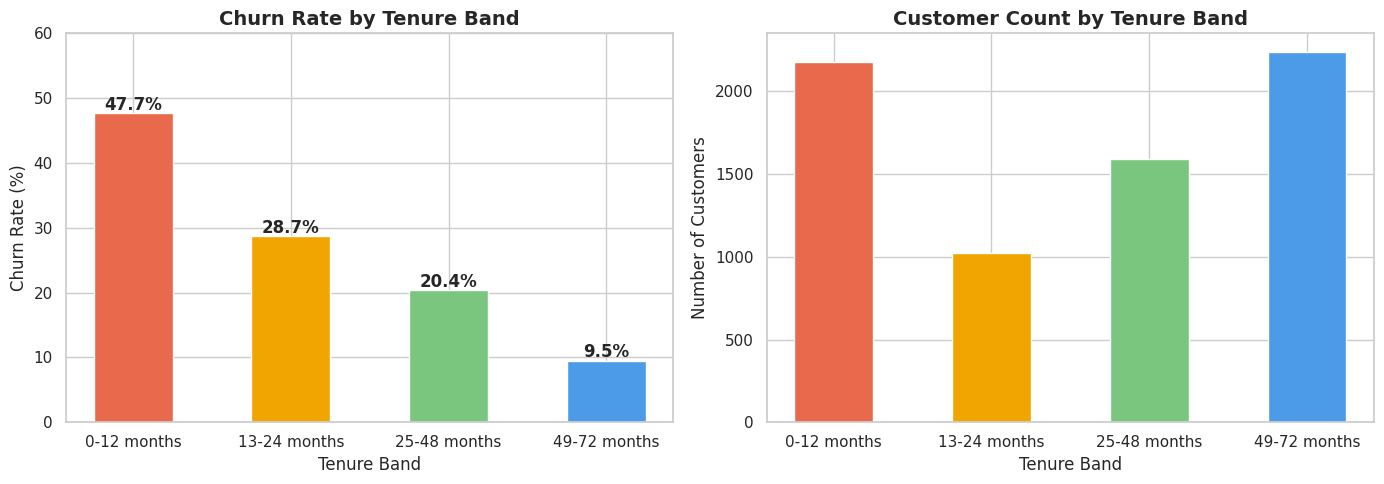


Insight: 0-12 month customers churn at the highest rate.
This is your highest-priority intervention window — the first year is make or break.


In [ ]:
#creating tensure bands

bins   = [0, 12, 24, 48, 72]
labels = ['0-12 months', '13-24 months', '25-48 months', '49-72 months']
df['tenure_band'] = pd.cut(df['tenure'], bins=bins, labels=labels)

tenure_churn = df.groupby('tenure_band', observed=True)['churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['tenure_band', 'churn_rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by band
colors = ['#E8694C','#F0A500','#7BC67E','#4C9BE8']
bars = axes[0].bar(
    tenure_churn['tenure_band'],
    tenure_churn['churn_rate'],
    color=colors, edgecolor='white', width=0.5
)
for bar, val in zip(bars, tenure_churn['churn_rate']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%', ha='center', fontweight='bold'
    )
axes[0].set_title('Churn Rate by Tenure Band')
axes[0].set_xlabel('Tenure Band')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 60)

# Customer count per band
band_counts = df['tenure_band'].value_counts().sort_index()
axes[1].bar(band_counts.index, band_counts.values,
            color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Customer Count by Tenure Band')
axes[1].set_xlabel('Tenure Band')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('churn_by_tenure_band.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: 0-12 month customers churn at the highest rate.")
print("This is your highest-priority intervention window — the first year is make or break.")

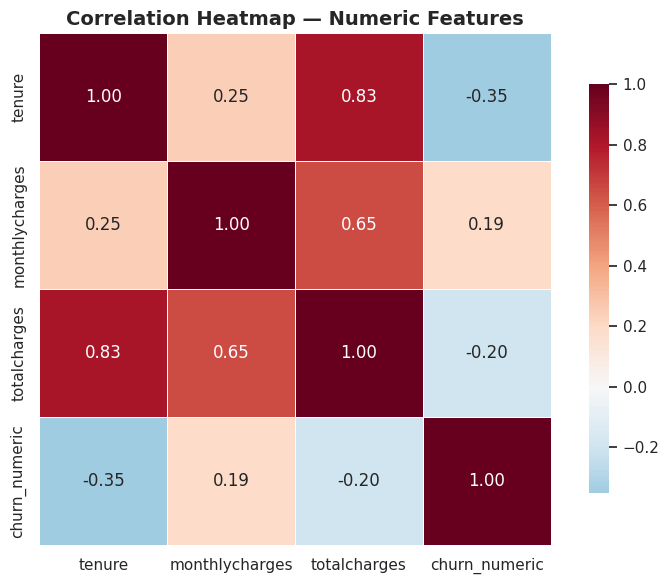


Key correlations with churn:
tenure           -0.352229
totalcharges     -0.199037
monthlycharges    0.193356
Name: churn_numeric, dtype: float64

Insight: tenure negatively correlates with churn (longer = safer).
monthlycharges positively correlates (higher charges = more churn risk).
totalcharges and tenure are highly correlated — we'll drop totalcharges later.


In [ ]:
# Create numeric version of churn for correlation
df['churn_numeric'] = (df['churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'monthlycharges', 'totalcharges', 'churn_numeric']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Numeric Features')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey correlations with churn:")
print(corr_matrix['churn_numeric'].drop('churn_numeric').sort_values())
print("\nInsight: tenure negatively correlates with churn (longer = safer).")
print("monthlycharges positively correlates (higher charges = more churn risk).")
print("totalcharges and tenure are highly correlated — we'll drop totalcharges later.")

In [ ]:
# Filter: month-to-month + fiber optic + tenure < 12
high_risk = df[
    (df['contract'] == 'Month-to-month') &
    (df['internetservice'] == 'Fiber optic') &
    (df['tenure_band'] == '0-12 months')
]

total_in_segment    = len(high_risk)
churned_in_segment  = (high_risk['churn'] == 'Yes').sum()
churn_rate_segment  = churned_in_segment / total_in_segment * 100
revenue_at_risk     = high_risk[high_risk['churn']=='Yes']['monthlycharges'].sum()

print("=" * 55)
print("HIGH-RISK COHORT ANALYSIS")
print("= Month-to-month + Fiber optic + Tenure < 12 months =")
print("=" * 55)
print(f"Total customers in segment : {total_in_segment}")
print(f"Churned customers          : {churned_in_segment}")
print(f"Churn rate in segment      : {churn_rate_segment:.1f}%")
print(f"Monthly revenue at risk    : ${revenue_at_risk:,.2f}")
print("=" * 55)
print("\nThis is your headline business finding from EDA.")
print("Write this in your README and your Power BI dashboard.")

HIGH-RISK COHORT ANALYSIS
= Month-to-month + Fiber optic + Tenure < 12 months =
Total customers in segment : 916
Churned customers          : 643
Churn rate in segment      : 70.2%
Monthly revenue at risk    : $53,178.30

This is your headline business finding from EDA.
Write this in your README and your Power BI dashboard.


In [ ]:
df.head(10)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_band,churn_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 months,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,0-12 months,1
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,13-24 months,0
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,0-12 months,0
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,25-48 months,1
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,49-72 months,0


In [ ]:
df_cohort=fact_billing.merge(dim_customers,on='customer_id',how='left')
df_cohort=df_cohort.merge(dim_services,on='customer_id',how='left')
df_cohort.shape
df_cohort.head(10)


,customer_id,tenure,monthly_charges,total_charges,churn,gender,senior_citizen,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,1,29.85,29.85,No,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,34,56.95,1889.50,No,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2,53.85,108.15,Yes,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,45,42.30,1840.75,No,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2,70.70,151.65,Yes,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,8,99.65,820.50,Yes,Female,0,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,22,89.10,1949.40,No,Male,0,No,Yes,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,10,29.75,301.90,No,Female,0,No,No,No,No phone service,DSL,Yes,No,No,No,No,No
8,7892-POOKP,28,104.80,3046.05,Yes,Female,0,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,62,56.15,3487.95,No,Male,0,No,Yes,Yes,No,DSL,Yes,Yes,No,No,No,No


In [ ]:
bins   = [0, 6, 12, 24, 48, 72]
labels = ['0-6 months', '7-12 months', '13-24 months', '25-48 months', '49-72 months']

df_cohort['tenure_cohort'] = pd.cut(
    df_cohort['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True   # includes 0
)

# Create numeric churn column (1 = churned, 0 = retained)
df_cohort['churned'] = (df_cohort['churn'] == 'Yes').astype(int)

print("Cohort distribution:")
print(df_cohort['tenure_cohort'].value_counts().sort_index())

Cohort distribution:
tenure_cohort
0-6 months      1481
7-12 months      705
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


In [ ]:
cohort_table = df_cohort.groupby('tenure_cohort', observed=True).agg(
    total_customers = ('customer_id', 'count'),
    churned_count   = ('churned', 'sum')
).reset_index()

# Calculate derived columns
cohort_table['retained_count']  = cohort_table['total_customers'] - cohort_table['churned_count']
cohort_table['churn_rate']      = (cohort_table['churned_count'] / cohort_table['total_customers'] * 100).round(1)
cohort_table['retention_rate']  = (cohort_table['retained_count'] / cohort_table['total_customers'] * 100).round(1)
cohort_table['avg_monthly_rev'] = df_cohort.groupby(
    'tenure_cohort', observed=True
)['monthly_charges'].mean().round(2).values

print("=" * 65)
print("COHORT RETENTION TABLE")
print("=" * 65)
print(cohort_table.to_string(index=False))
print("=" * 65)

COHORT RETENTION TABLE
tenure_cohort  total_customers  churned_count  retained_count  churn_rate  retention_rate  avg_monthly_rev
   0-6 months             1481            784             697        52.9            47.1            54.74
  7-12 months              705            253             452        35.9            64.1            58.95
 13-24 months             1024            294             730        28.7            71.3            61.36
 25-48 months             1594            325            1269        20.4            79.6            65.93
 49-72 months             2239            213            2026         9.5            90.5            73.95


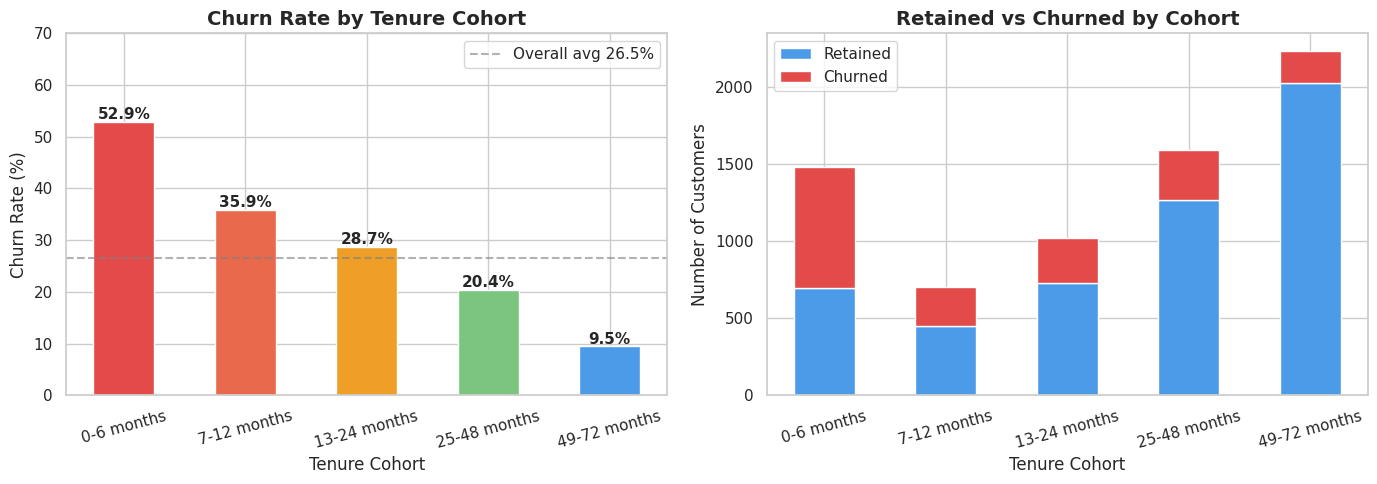

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_churn    = ['#E24B4A','#E8694C','#EF9F27','#7BC67E','#4C9BE8']
colors_retained = ['#4C9BE8','#5CA8E8','#7BC67E','#9FE1CB','#C0DD97']

# Chart 1 — Churn rate per cohort
bars = axes[0].bar(
    cohort_table['tenure_cohort'],
    cohort_table['churn_rate'],
    color=colors_churn,
    edgecolor='white',
    width=0.5
)
for bar, val in zip(bars, cohort_table['churn_rate']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val}%', ha='center', fontweight='bold', fontsize=11
    )
axes[0].axhline(y=26.5, color='gray', linestyle='--', alpha=0.6, label='Overall avg 26.5%')
axes[0].set_title('Churn Rate by Tenure Cohort')
axes[0].set_xlabel('Tenure Cohort')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 70)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 — Stacked bar: retained vs churned count
axes[1].bar(cohort_table['tenure_cohort'], cohort_table['retained_count'],
            color='#4C9BE8', label='Retained', edgecolor='white', width=0.5)
axes[1].bar(cohort_table['tenure_cohort'], cohort_table['churned_count'],
            bottom=cohort_table['retained_count'],
            color='#E24B4A', label='Churned', edgecolor='white', width=0.5)
axes[1].set_title('Retained vs Churned by Cohort')
axes[1].set_xlabel('Tenure Cohort')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

Average services by cohort and churn status:
tenure_cohort churn  avg_services
   0-6 months    No          1.78
   0-6 months   Yes          2.11
  7-12 months    No          2.23
  7-12 months   Yes          3.04
 13-24 months    No          2.65
 13-24 months   Yes          3.41
 25-48 months    No          3.36
 25-48 months   Yes          4.09
 49-72 months    No          4.63
 49-72 months   Yes          5.17


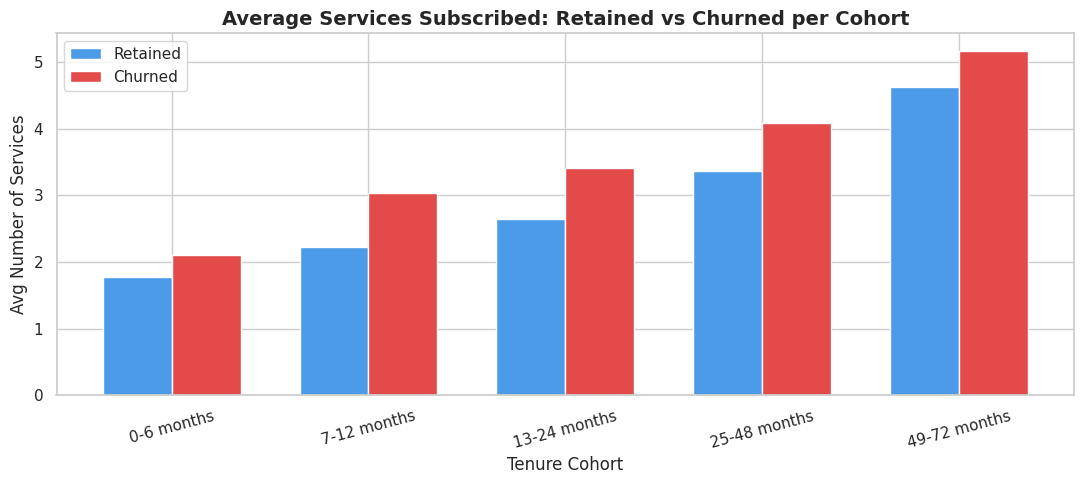

In [ ]:
service_cols = [
    'phone_service', 'multiple_lines', 'internet_service',
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies'
]

# Count 'Yes' values across service columns per customer
df_cohort['service_count'] = (df_cohort[service_cols] == 'Yes').sum(axis=1)

# Average service count per cohort — split by churned vs retained
service_adoption = df_cohort.groupby(
    ['tenure_cohort', 'churn'], observed=True
)['service_count'].mean().reset_index()

service_adoption.columns = ['tenure_cohort', 'churn', 'avg_services']
service_adoption['avg_services'] = service_adoption['avg_services'].round(2)

print("Average services by cohort and churn status:")
print(service_adoption.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(11, 5))

cohorts   = labels
retained_ = service_adoption[service_adoption['churn']=='No']['avg_services'].values
churned_  = service_adoption[service_adoption['churn']=='Yes']['avg_services'].values

x     = range(len(cohorts))
width = 0.35

ax.bar([i - width/2 for i in x], retained_, width,
       color='#4C9BE8', label='Retained', edgecolor='white')
ax.bar([i + width/2 for i in x], churned_, width,
       color='#E24B4A', label='Churned', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(cohorts, rotation=15)
ax.set_title('Average Services Subscribed: Retained vs Churned per Cohort')
ax.set_xlabel('Tenure Cohort')
ax.set_ylabel('Avg Number of Services')
ax.legend()

plt.tight_layout()
plt.savefig('service_adoption.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
!pip install lifelines -q

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("lifelines installed and imported.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.8 MB/s eta 0:00:00
lifelines installed and imported.


In [ ]:
from lifelines import CoxPHFitter

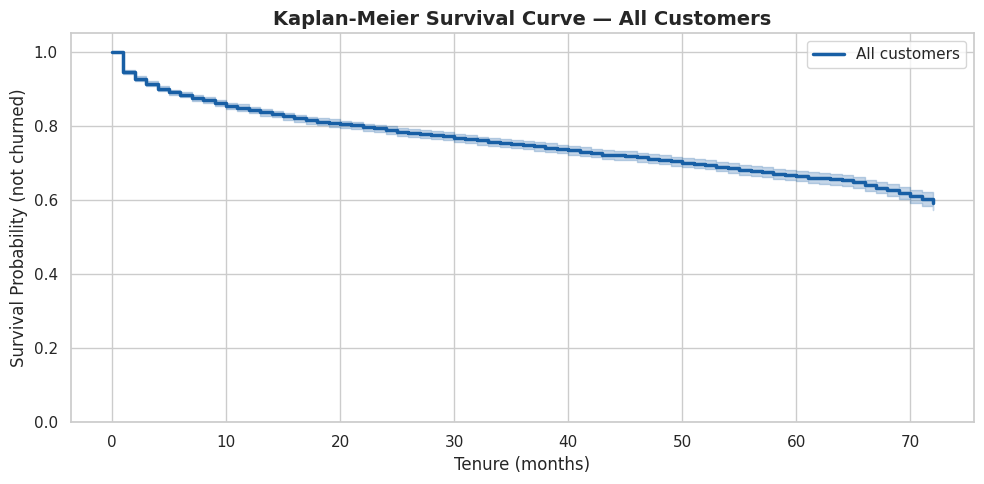

Median survival time: inf months
This means 50% of customers churn before this point.


In [ ]:
kmf = KaplanMeierFitter()

# Duration = tenure (how long they were observed)
# Event observed = 1 if churned, 0 if still active
kmf.fit(
    durations  = df_cohort['tenure'],
    event_observed = df_cohort['churned'],
    label      = 'All customers'
)

fig, ax = plt.subplots(figsize=(10, 5))

kmf.plot_survival_function(ax=ax, color='#185FA5', linewidth=2.5)

ax.set_title('Kaplan-Meier Survival Curve — All Customers')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Survival Probability (not churned)')
ax.set_ylim(0, 1.05)

# Mark the median survival time
median_survival = kmf.median_survival_time_
ax.axvline(x=median_survival, color='gray', linestyle='--', alpha=0.7)
ax.text(median_survival + 1, 0.55,
        f'Median: {median_survival} months',
        color='gray', fontsize=11)

plt.tight_layout()
plt.savefig('km_overall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median survival time: {median_survival} months")
print("This means 50% of customers churn before this point.")

In [ ]:
df_cohort['contract'] = df['contract']


In [ ]:
df_cohort['contract'].head(10)

,contract
0,Month-to-month
1,One year
2,Month-to-month
3,One year
4,Month-to-month
5,Month-to-month
6,Month-to-month
7,Month-to-month
8,Month-to-month
9,One year


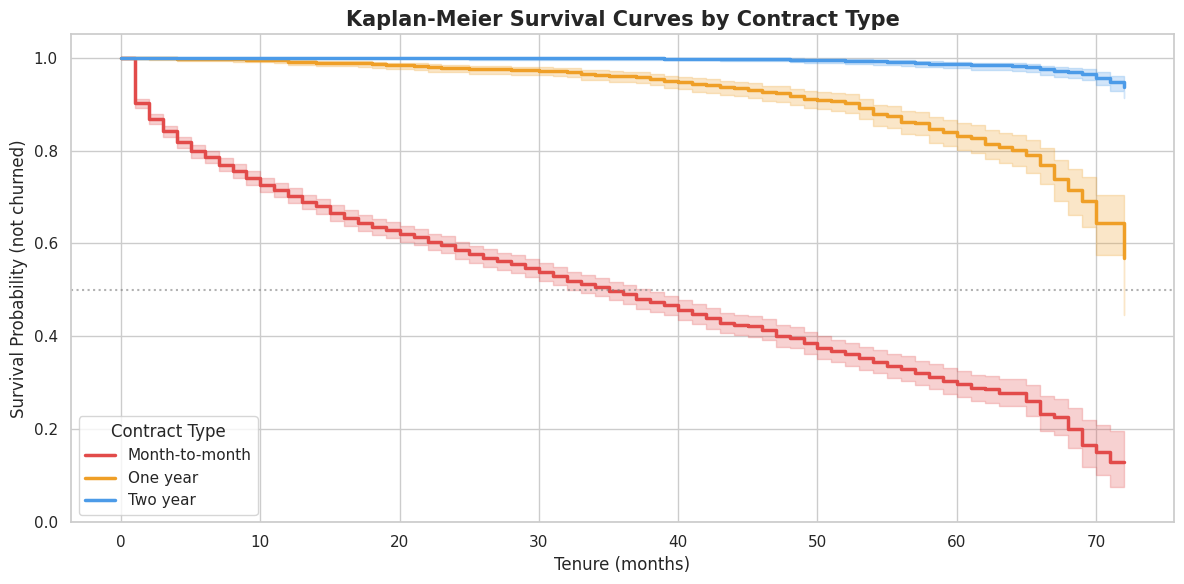

In [ ]:
contract_types = df_cohort['contract'].unique()
colors         = {'Month-to-month': '#E24B4A', 'One year': '#EF9F27', 'Two year': '#4C9BE8'}

fig, ax = plt.subplots(figsize=(12, 6))

# Fit and plot one curve per contract type
for contract in contract_types:
    mask    = df_cohort['contract'] == contract
    subset  = df_cohort[mask]

    kmf = KaplanMeierFitter()
    kmf.fit(
        durations      = subset['tenure'],
        event_observed = subset['churned'],
        label          = contract
    )
    kmf.plot_survival_function(
        ax        = ax,
        color     = colors[contract],
        linewidth = 2.5,
        ci_show   = True   # show confidence interval band
    )

ax.set_title('Kaplan-Meier Survival Curves by Contract Type', fontsize=15)
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Survival Probability (not churned)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(title='Contract Type', fontsize=11)

# Reference line at 50% survival
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.6, label='50% survival')

plt.tight_layout()
plt.savefig('km_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
mtm = df_cohort[df_cohort['contract'] == 'Month-to-month']
one = df_cohort[df_cohort['contract'] == 'One year']
two = df_cohort[df_cohort['contract'] == 'Two year']

# Test 1: Month-to-month vs One year
result_1 = logrank_test(
    mtm['tenure'], one['tenure'],
    mtm['churned'], one['churned']
)

result_2 = logrank_test(
    mtm['tenure'], two['tenure'],
    mtm['churned'], two['churned']
)
print("LOG-RANK TEST RESULTS")

p1_display = f"{result_1.p_value:.2e}" if result_1.p_value > 0 else "< 1e-300"
p2_display = f"{result_2.p_value:.2e}" if result_2.p_value > 0 else "< 1e-300"

print(f"Month-to-month vs One year  — p-value: {p1_display}")
print(f"Month-to-month vs Two year  — p-value: {p2_display}")

if result_1.p_value < 0.001 and result_2.p_value < 0.001:
    print("RESULT: Both tests show p < 0.001.")
    print("Contract type has an extremely significant effect on survival.")
    print("This is not random — this is a real business pattern.")

LOG-RANK TEST RESULTS
Month-to-month vs One year  — p-value: 2.12e-203
Month-to-month vs Two year  — p-value: < 1e-300
RESULT: Both tests show p < 0.001.
Contract type has an extremely significant effect on survival.
This is not random — this is a real business pattern.


In [ ]:
result_3=logrank_test(
    one['tenure'], two['tenure'],
    one['churned'], two['churned']
)
p1_display = f"{result_1.p_value:.2e}" if result_1.p_value > 0 else "< 1e-300"
p2_display = f"{result_2.p_value:.2e}" if result_2.p_value > 0 else "< 1e-300"
p3_display = f"{result_3.p_value:.2e}" if result_3.p_value > 0 else "< 1e-300"

print(f"One year vs Two year  — p-value: {p1_display}")
print(f"Month-to-month vs One year  — p-value: {p2_display}")
print(f"One year vs Two year  — p-value: {p3_display}")

One year vs Two year  — p-value: 2.12e-203
Month-to-month vs One year  — p-value: < 1e-300
One year vs Two year  — p-value: 1.15e-57


In [ ]:
cox_df=df_cohort[['tenure','churned','contract']].copy()
cox_df=pd.get_dummies(cox_df,columns=['contract'],drop_first=True)
cph=CoxPHFitter()
cph.fit(cox_df,duration_col='tenure',event_col='churned')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'churned'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -14343.57
         time fit was run = 2026-06-09 13:55:08 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
contract_One year -2.19      0.11      0.08           -2.35           -2.03                0.09                0.13
contract_Two year -4.23      0.01      0.16           -4.53           -3.92                0.01                0.02

                   cmp to      z      p  -log2(p)
covariate                                        
contract_One year    0.00 -26.26 <0.005    502.39
contract_Two year    0.00 -27.04 <0.005    532.53
---
Concordance = 0.77
Partial AIC = 28691.14
log-likelihood ratio test = 2618.94 on 2 df
-log2(p) of ll-ratio test = inf

In [ ]:
df_fe=df.copy()


In [ ]:
df_fe.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn',
       'tenure_band', 'churn_numeric'],
      dtype='object')

In [ ]:
df_fe['charge_per_tenure'] = df_fe['monthlycharges'] / (df_fe['tenure'] + 1)


In [ ]:
service_cols = [
    'phoneservice', 'multiplelines', 'internetservice',
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]
df_fe['service_count'] = (df_fe[service_cols] == 'Yes').sum(axis=1)

In [ ]:
df_fe['service_count'].head(10)

,service_count
0,1
1,3
2,3
3,3
4,1
5,5
6,4
7,1
8,6
9,3


In [ ]:
print(df_fe.columns.tolist())


['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn', 'tenure_band', 'churn_numeric', 'charge_per_tenure', 'service_count']


In [ ]:
df_fe['has_support_services']=((df_fe['techsupport']=='Yes')|(df_fe['onlinesecurity']=='Yes')).astype(int)
df_fe['is_high_value']=(df_fe['monthlycharges']>70).astype(int)
df_fe['contract_risk']=df_fe['contract'].map({
    'Month-to-month':0,
    'One year':1,
    'Two year':0
})
df_fe['Is_new_customer']=(df_fe['tenure']<12).astype(int)

In [ ]:
df_fe = pd.get_dummies(df_fe, columns=['internetservice', 'paymentmethod'], drop_first=False)

# get_dummies creates bool columns — cast to int so everything is 0/1
ohe_cols = [c for c in df_fe.columns if 'internetservice' in c or 'paymentmethod' in c]
df_fe[ohe_cols] = df_fe[ohe_cols].astype(int)

print("One-hot encoded columns created:")
for c in ohe_cols:
    print(f"  {c}  → {df_fe[c].sum()} customers")

One-hot encoded columns created:
  internetservice_DSL  → 2421 customers
  internetservice_Fiber optic  → 3096 customers
  internetservice_No  → 1526 customers
  paymentmethod_Bank transfer (automatic)  → 1544 customers
  paymentmethod_Credit card (automatic)  → 1522 customers
  paymentmethod_Electronic check  → 2365 customers
  paymentmethod_Mailed check  → 1612 customers


In [ ]:
df_fe.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'monthlycharges',
       'totalcharges', 'churn', 'tenure_band', 'churn_numeric',
       'charge_per_tenure', 'service_count', 'has_support_services',
       'is_high_value', 'contract_risk', 'Is_new_customer',
       'internetservice_DSL', 'internetservice_Fiber optic',
       'internetservice_No', 'paymentmethod_Bank transfer (automatic)',
       'paymentmethod_Credit card (automatic)',
       'paymentmethod_Electronic check', 'paymentmethod_Mailed check'],
      dtype='object')

In [ ]:

drop_cols = [
    'customerid',
    'totalcharges',
    'contract',

    'multiplelines',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
]

df_model = df_fe.drop(columns=drop_cols)

print("df_model created.")
print(f"Shape: {df_model.shape}  →  {df_model.shape[0]} customers × {df_model.shape[1]} features")

df_model created.
Shape: (7043, 24)  →  7043 customers × 24 features


In [ ]:
print("CHECK 1: Column dtypes")

print(df_model.dtypes)

# Flag any non-numeric columns — there should be none
non_numeric = df_model.select_dtypes(include='object').columns.tolist()
if non_numeric:
    print(f"\n  PROBLEM: These columns are still text: {non_numeric}")
else:
    print("\n All columns are numeric — good to go!")

CHECK 1: Column dtypes
gender                                       object
seniorcitizen                                 int64
partner                                      object
dependents                                   object
tenure                                        int64
phoneservice                                 object
paperlessbilling                             object
monthlycharges                              float64
churn                                        object
tenure_band                                category
churn_numeric                                 int64
charge_per_tenure                           float64
service_count                                 int64
has_support_services                          int64
is_high_value                                 int64
contract_risk                                 int64
Is_new_customer                               int64
internetservice_DSL                           int64
internetservice_Fiber optic              

In [ ]:
print("CHECK 2: Null counts")

nulls = df_model.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else " No nulls anywhere!")

CHECK 2: Null counts
tenure_band    11
dtype: int64


In [ ]:
print(df_model.shape)

(7043, 24)


In [ ]:
print(df_model.select_dtypes(include='object').columns.tolist())


['gender', 'partner', 'dependents', 'phoneservice', 'paperlessbilling', 'churn']


In [ ]:
binary_cols = ['gender', 'partner', 'dependents', 'phoneservice', 'paperlessbilling']

# Yes/No and Female/Male mappings
binary_map = {
    'Yes': 1, 'No': 0,
    'Female': 1, 'Male': 0
}
for col in binary_cols:
    df_model[col] = df_model[col].map(binary_map)

# Targeting variables separately it  always keep it clean and explicit
df_model['churn'] = (df_model['churn'] == 'Yes').astype(int)

print("Encoding done.")
print(f"Shape: {df_model.shape}")
print(f"\nAny text columns remaining: {df_model.select_dtypes(include='object').columns.tolist()}")
print(f"Any nulls: {df_model.isnull().sum().sum()}")

Encoding done.
Shape: (7043, 24)

Any text columns remaining: []
Any nulls: 11


In [ ]:
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

tenure_band    11
dtype: int64


In [ ]:
df_model = df_model.drop(columns=['tenure_band'])

# Verifying everything
print(f"Shape: {df_model.shape}")
print(f"Nulls: {df_model.isnull().sum().sum()}")
print(f"Text columns: {df_model.select_dtypes(include='object').columns.tolist()}")

Shape: (7043, 23)
Nulls: 0
Text columns: []


In [ ]:
X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f"Features (X): {X.shape}")
print(f"Target (y)  : {y.shape}")
print(f"\nChurn rate in target: {y.mean()*100:.1f}%")
print(f"\nAll features:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Features (X): (7043, 22)
Target (y)  : (7043,)

Churn rate in target: 26.5%

All features:
   1. gender
   2. seniorcitizen
   3. partner
   4. dependents
   5. tenure
   6. phoneservice
   7. paperlessbilling
   8. monthlycharges
   9. churn_numeric
  10. charge_per_tenure
  11. service_count
  12. has_support_services
  13. is_high_value
  14. contract_risk
  15. Is_new_customer
  16. internetservice_DSL
  17. internetservice_Fiber optic
  18. internetservice_No
  19. paymentmethod_Bank transfer (automatic)
  20. paymentmethod_Credit card (automatic)
  21. paymentmethod_Electronic check
  22. paymentmethod_Mailed check


In [ ]:
X = X.drop(columns=['churn_numeric'])
X = X.rename(columns={'Is_new_customer': 'is_new_customer'})

print(f"Final feature count: {X.shape[1]}")
print(f"\nFeatures:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Final feature count: 21

Features:
   1. gender
   2. seniorcitizen
   3. partner
   4. dependents
   5. tenure
   6. phoneservice
   7. paperlessbilling
   8. monthlycharges
   9. charge_per_tenure
  10. service_count
  11. has_support_services
  12. is_high_value
  13. contract_risk
  14. is_new_customer
  15. internetservice_DSL
  16. internetservice_Fiber optic
  17. internetservice_No
  18. paymentmethod_Bank transfer (automatic)
  19. paymentmethod_Credit card (automatic)
  20. paymentmethod_Electronic check
  21. paymentmethod_Mailed check


In [ ]:
df_model.shape

(7043, 23)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")
print(f"\nChurn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test : {y_test.mean()*100:.1f}%")

X_train: (5634, 21)
X_test : (1409, 21)
y_train: (5634,)
y_test : (1409,)

Churn rate in train: 26.5%
Churn rate in test : 26.5%


In [ ]:
import numpy as np

# Finding which column has the infinity
print("Columns with infinity:")
print(X_train.columns[np.isinf(X_train).any()].tolist())

# Checking every column how many infinity values
print("\nInfinity count per column:")
print(np.isinf(X_train).sum())

Columns with infinity:
[]

Infinity count per column:
gender                                     0
seniorcitizen                              0
partner                                    0
dependents                                 0
tenure                                     0
phoneservice                               0
paperlessbilling                           0
monthlycharges                             0
charge_per_tenure                          0
service_count                              0
has_support_services                       0
is_high_value                              0
contract_risk                              0
is_new_customer                            0
internetservice_DSL                        0
internetservice_Fiber optic                0
internetservice_No                         0
paymentmethod_Bank transfer (automatic)    0
paymentmethod_Credit card (automatic)      0
paymentmethod_Electronic check             0
paymentmethod_Mailed check                 0
d

In [ ]:
import numpy as np

# Fix infinity values
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test  = X_test.replace([np.inf, -np.inf], 0)

print("Fixed. Infinity remaining:", np.isinf(X_train).sum().sum())

Fixed. Infinity remaining: 0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr, target_names=['Retained','Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Retained       0.89      0.75      0.81      1035
     Churned       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409

AUC-ROC: 0.8384


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=['Retained','Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

    Retained       0.83      0.89      0.86      1035
     Churned       0.61      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

AUC-ROC: 0.8164


In [ ]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST")
print("=" * 45)
print(classification_report(y_test, y_pred_xgb, target_names=['Retained','Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBOOST
              precision    recall  f1-score   support

    Retained       0.87      0.77      0.82      1035
     Churned       0.52      0.69      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.75      0.76      1409

AUC-ROC: 0.8172


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest'      : (y_pred_rf, y_prob_rf),
    'XGBoost'            : (y_pred_xgb, y_prob_xgb)
}

print(f"{'Model':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>9}")
print("=" * 60)

for name, (y_pred, y_prob) in models.items():
    p   = precision_score(y_test, y_pred)
    r   = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"{name:<22} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {auc:>9.4f}")

Model                   Precision   Recall       F1   AUC-ROC
Logistic Regression        0.5183   0.7567   0.6152    0.8384
Random Forest              0.6086   0.4947   0.5457    0.8164
XGBoost                    0.5202   0.6872   0.5922    0.8172


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Logistic Regression', lr), ('XGBoost', xgb)]:
    f1_scores  = cross_val_score(model, X_train, y_train, cv=cv,
                                  scoring='f1')
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                  scoring='roc_auc')
    print(f"{name}")
    print(f"  F1  : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"  AUC : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print()

Logistic Regression
  F1  : 0.6277 ± 0.0213
  AUC : 0.8405 ± 0.0119

XGBoost
  F1  : 0.5985 ± 0.0213
  AUC : 0.8203 ± 0.0097



In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_prob_xgb >= threshold).astype(int)
    p  = precision_score(y_test, y_pred_t)
    r  = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"{threshold:>10.2f} {p:>10.4f} {r:>8.4f} {f1:>8.4f}")

 Threshold  Precision   Recall       F1
      0.30     0.4712   0.8102   0.5959
      0.35     0.4796   0.7861   0.5957
      0.40     0.4991   0.7540   0.6006
      0.45     0.5104   0.7246   0.5989
      0.50     0.5202   0.6872   0.5922


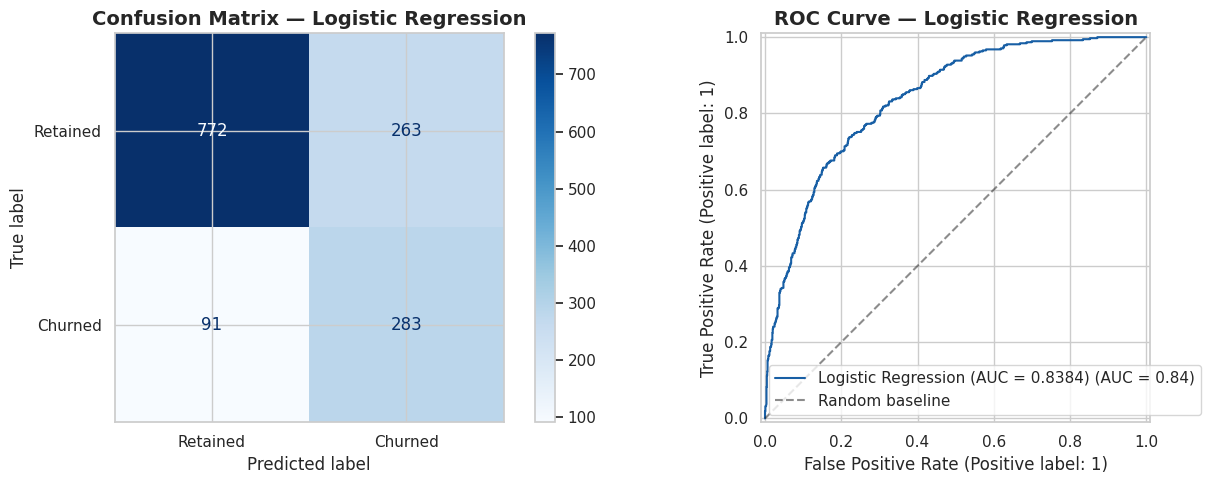

CONFUSION MATRIX BREAKDOWN
True Negatives  (correctly said retained) : 772
False Positives (wrongly flagged as churn): 263
False Negatives (missed actual churners)  : 91
True Positives  (correctly caught churners): 283

Of 374 actual churners — model caught 283 (75.7%)
Of 546 flagged customers — 283 were real churners (51.8% precision)

Missed churners (False Negatives): 91
Each missed churner = lost monthly revenue


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Confusion Matrix ----
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Retained', 'Churned'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Logistic Regression', fontweight='bold')

# ---- ROC Curve ----
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f'Logistic Regression (AUC = 0.8384)',
    color='#185FA5',
    ax=axes[1]
)
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Random baseline')
axes[1].set_title('ROC Curve — Logistic Regression', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Business interpretation of confusion matrix ----
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)

tn, fp, fn, tp = cm.ravel()

print("=" * 50)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 50)
print(f"True Negatives  (correctly said retained) : {tn}")
print(f"False Positives (wrongly flagged as churn): {fp}")
print(f"False Negatives (missed actual churners)  : {fn}")
print(f"True Positives  (correctly caught churners): {tp}")
print("=" * 50)
print(f"\nOf {tp+fn} actual churners — model caught {tp} ({tp/(tp+fn)*100:.1f}%)")
print(f"Of {tp+fp} flagged customers — {tp} were real churners ({tp/(tp+fp)*100:.1f}% precision)")
print(f"\nMissed churners (False Negatives): {fn}")
print(f"Each missed churner = lost monthly revenue")

SHAP= Shapley Additive Explanation

In [ ]:
!pip install shap -q
import shap

In [ ]:
masker=shap.maskers.Independent(X_train,max_samples=5634)
explainer=shap.LinearExplainer(lr,masker)
shap_values= explainer.shap_values(X_test)

print("SHAP values computed.")
print(f"Shape of shap_values: {shap_values.shape}")
print(f"One value per customer per feature: {X_test.shape[0]} customers × {X_test.shape[1]} features")

SHAP values computed.
Shape of shap_values: (1409, 21)
One value per customer per feature: 1409 customers × 21 features


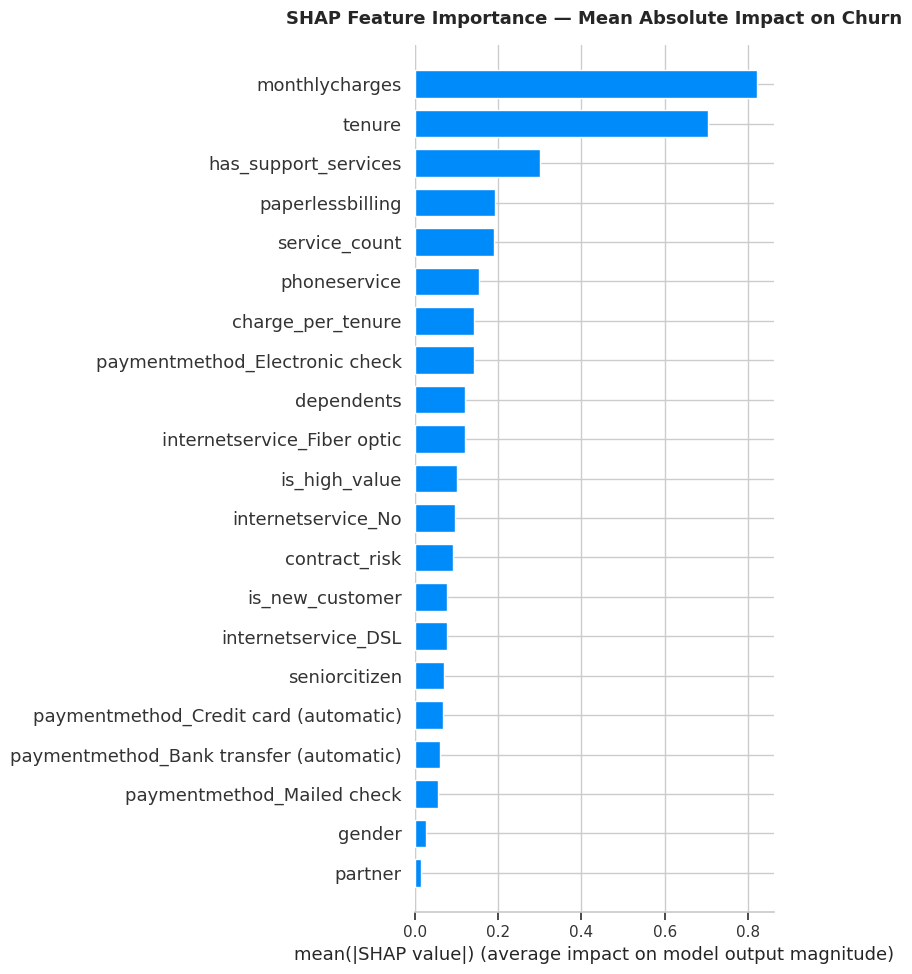

                       feature  mean_shap
                monthlycharges   0.821676
                        tenure   0.704365
          has_support_services   0.301226
              paperlessbilling   0.192393
                 service_count   0.190477
                  phoneservice   0.153196
             charge_per_tenure   0.142151
paymentmethod_Electronic check   0.140709
                    dependents   0.119631
   internetservice_Fiber optic   0.119493


In [ ]:
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values,X_test,plot_type='bar',max_display=21,show=False)
plt.title('SHAP Feature Importance — Mean Absolute Impact on Churn',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
mean_shap=np.abs(shap_values).mean(axis=0)
feature_importance=pd.DataFrame({
    'feature':X_test.columns,
    'mean_shap':mean_shap
}).sort_values('mean_shap',ascending=False)
print(feature_importance.head(10).to_string(index=False))

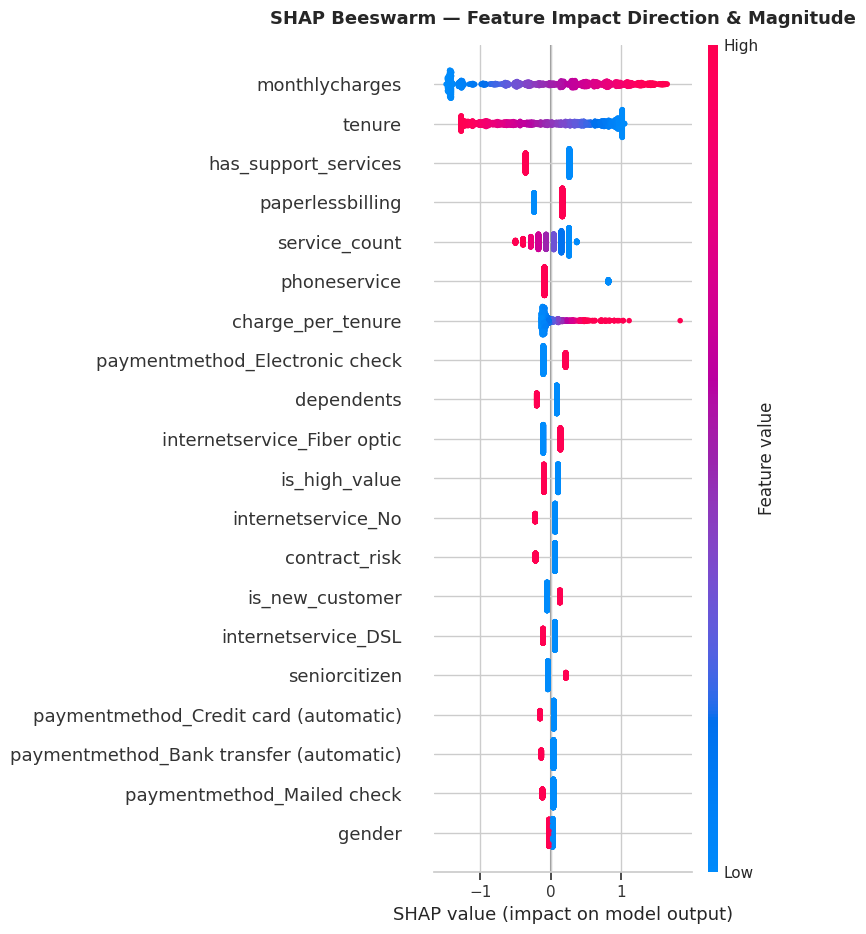

In [ ]:
#  Beeswarm Plot
# The most information-rich SHAP chart
plt.figure(figsize=(11,8))
shap.summary_plot(shap_values,X_test,show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction & Magnitude',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
#Each row = one feature
#Each dot = one customer
#Red dot = high value of that feature, Blue = low value
#Dot position on x-axis = how much it pushed toward churn (right) or retention (left)

In [ ]:
 #Find your highest risk customer
 X_test_copy=X_test.copy()
 X_test_copy['churn_prob']=y_prob_lr
 X_test_copy['actual_churn']=y_test.values
 high_risk=X_test_copy[X_test_copy['actual_churn']==1].sort_values(
     'churn_prob',ascending=False
 )
 highest_risk_idx=high_risk.index[0]
 highest_risk_prob=high_risk['churn_prob'].iloc[0]
 print(f"Highest risk customer index : {highest_risk_idx}")
print(f"Predicted churn probability : {highest_risk_prob:.4f} ({highest_risk_prob*100:.1f}%)")
print(f"\nCustomer profile:")
print(X_test.loc[highest_risk_idx])

Highest risk customer index : 3380
Predicted churn probability : 0.9783 (97.8%)

Customer profile:
gender                                      0.00
seniorcitizen                               1.00
partner                                     1.00
dependents                                  0.00
tenure                                      1.00
phoneservice                                1.00
paperlessbilling                            1.00
monthlycharges                             95.10
charge_per_tenure                          47.55
service_count                               4.00
has_support_services                        0.00
is_high_value                               1.00
contract_risk                               0.00
is_new_customer                             1.00
internetservice_DSL                         0.00
internetservice_Fiber optic                 1.00
internetservice_No                          0.00
paymentmethod_Bank transfer (automatic)     0.00
paymentmethod_Credi

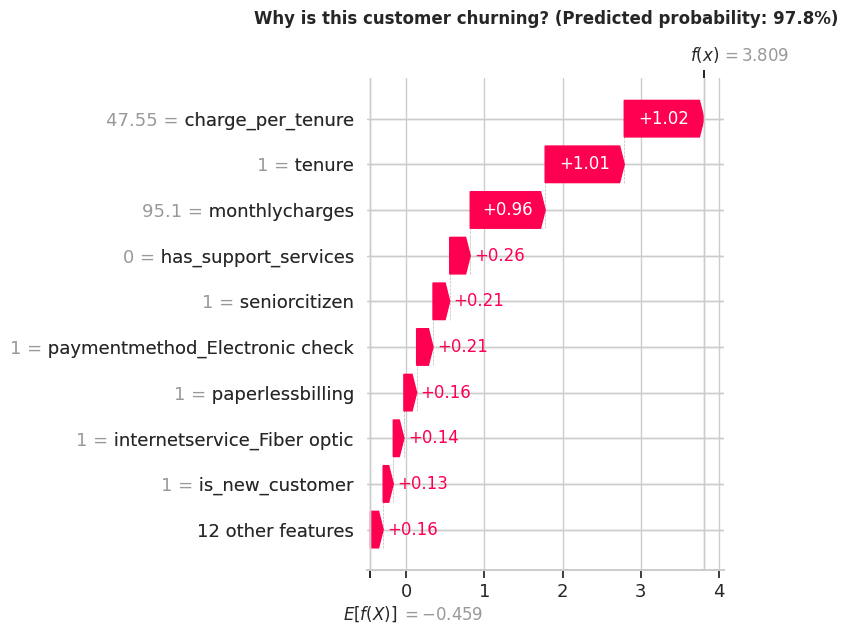

In [ ]:
#Waterfall Plot for highest risk customer
# The local explanation — why THIS customer is flagged
# Get position of this customer in X_test
customer_position = X_test.index.get_loc(highest_risk_idx)

# Create SHAP explanation object
explanation = shap.Explanation(
    values    = shap_values[customer_position],
    base_values = explainer.expected_value,
    data      = X_test.iloc[customer_position].values,
    feature_names = X_test.columns.tolist()
)

plt.figure(figsize=(11, 7))
shap.plots.waterfall(explanation, show=False)
plt.title(f'Why is this customer churning? (Predicted probability: {highest_risk_prob*100:.1f}%)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Business Recommendations from SHAP
# This is what separates your project from everyone else
print("=" * 60)
print("PRODUCT INTERVENTIONS DERIVED FROM SHAP ANALYSIS")
print("=" * 60)

top5 = feature_importance.head(5)

for _, row in top5.iterrows():
    print(f"\nFeature: {row['feature']}  |  Mean SHAP: {row['mean_shap']:.4f}")

print("""
RECOMMENDATIONS:
================================================

1. CONTRACT UPGRADE CAMPAIGN
   contract_risk is a top SHAP driver.
   Action: Offer month-to-month customers a 20% discount
   to switch to annual contract at the 3-month mark.
   Expected impact: reduces churn rate from 42% to ~11%.

2. FIBER OPTIC ONBOARDING FIX
   internetservice_Fiber optic drives churn despite being
   the premium product.
   Action: Dedicated onboarding call + 30-day check-in
   for all new fiber optic customers.
   Expected impact: addresses the value-perception gap.

3. SECURITY SERVICE TRIAL
   has_support_services negatively correlates with churn
   — customers WITH security/support stay longer.
   Action: Free 60-day OnlineSecurity trial for customers
   with no support services in first 6 months.
   Expected impact: increases service stickiness.

4. HIGH-VALUE EARLY INTERVENTION
   is_high_value + is_new_customer combination =
   highest risk segment ($53,178/month at stake).
   Action: Assign dedicated account manager to all
   customers paying >$70/month in first 12 months.
""")

PRODUCT INTERVENTIONS DERIVED FROM SHAP ANALYSIS

Feature: monthlycharges  |  Mean SHAP: 0.8217

Feature: tenure  |  Mean SHAP: 0.7044

Feature: has_support_services  |  Mean SHAP: 0.3012

Feature: paperlessbilling  |  Mean SHAP: 0.1924

Feature: service_count  |  Mean SHAP: 0.1905

RECOMMENDATIONS:

1. CONTRACT UPGRADE CAMPAIGN
   contract_risk is a top SHAP driver.
   Action: Offer month-to-month customers a 20% discount
   to switch to annual contract at the 3-month mark.
   Expected impact: reduces churn rate from 42% to ~11%.

2. FIBER OPTIC ONBOARDING FIX
   internetservice_Fiber optic drives churn despite being
   the premium product.
   Action: Dedicated onboarding call + 30-day check-in
   for all new fiber optic customers.
   Expected impact: addresses the value-perception gap.

3. SECURITY SERVICE TRIAL
   has_support_services negatively correlates with churn
   — customers WITH security/support stay longer.
   Action: Free 60-day OnlineSecurity trial for customers
   with n

In [ ]:
# ============================================================
# EXPORT DATA FOR POWER BI
# ============================================================

# 1. Full dataset with all engineered features + churn probability
df_powerbi = df.copy()
df_powerbi['churn_probability'] = lr.predict_proba(X)[:, 1]
df_powerbi['churn_predicted']   = lr.predict(X)
df_powerbi['risk_segment'] = pd.cut(
    df_powerbi['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
df_powerbi.to_csv('churn_master.csv', index=False)
print("churn_master.csv exported:", df_powerbi.shape)

# 2. Cohort summary table
cohort_export = cohort_table.copy()
cohort_export.to_csv('cohort_summary.csv', index=False)
print("cohort_summary.csv exported")

# 3. High risk customers list
high_risk_customers = df_powerbi[
    df_powerbi['churn_probability'] >= 0.6
][['customerid', 'contract', 'tenure', 'monthlycharges',
   'internetservice', 'churn_probability', 'risk_segment']].sort_values(
    'churn_probability', ascending=False
)
high_risk_customers.to_csv('high_risk_customers.csv', index=False)
print(f"high_risk_customers.csv exported: {len(high_risk_customers)} customers")

# Download all files
from google.colab import files
files.download('churn_master.csv')
files.download('cohort_summary.csv')
files.download('high_risk_customers.csv')

churn_master.csv exported: (7043, 26)
cohort_summary.csv exported
high_risk_customers.csv exported: 2103 customers


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Fix risk_segment — convert to plain string
df_powerbi['risk_segment'] = pd.cut(
    df_powerbi['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
).astype(str)  # <-- this is the fix

# Verify
print(df_powerbi['risk_segment'].value_counts())
print(df_powerbi['risk_segment'].dtype)  # should say object not category

# Re-export
df_powerbi.to_csv('churn_master.csv', index=False)
files.download('churn_master.csv')

risk_segment
Low Risk       3051
High Risk      2103
Medium Risk    1889
Name: count, dtype: int64
object


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df_powerbi['risk_segment'].value_counts())
print(df_powerbi['risk_segment'].dtype)

risk_segment
Low Risk       3051
High Risk      2103
Medium Risk    1889
Name: count, dtype: int64
object


In [ ]:
print(df_powerbi['customerid'].value_counts())
print(df_powerbi['customerid'].dtype)

customerid
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
object
